# Boston Crime Incident Reports — Complete Analysis
**Dataset:** Boston Police Department (BPD) crime incident reports  
**Coverage:** June 2015 – 2026 (original Kaggle data + supplementary annual files)  
**Questions addressed:**
1. What types of crimes are most common?
2. Where are different types of crimes most likely to occur?
3. Does crime frequency change over the day / week / year?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

print('Libraries loaded.')

Libraries loaded.


---
## 1  Load & Merge All Data

In [2]:
import glob, os

DATA_DIR = '.'  # all CSVs sit in the same folder as this notebook

# ---------- supplementary annual files (2019-2026) ----------
supp_files = [
    'tmp6w6ts2d7.csv',   # 2019
    'tmpkd_w64k_.csv',   # 2020
    'tmpfap3hfze.csv',   # 2021
    'tmpdfeo3qy2.csv',   # 2022
    'tmpcyl1hw5w.csv',   # 2023-2026
]

def load_file(path):
    df = pd.read_csv(path, encoding='latin-1', low_memory=False)
    # 2023+ files store tz-aware strings (e.g. "2023-01-27 22:44:00+00").
    # Parsing with utc=True handles both tz-aware and tz-naive strings in one pass,
    # then we strip the timezone so all files share the same tz-naive dtype for concat.
    df['OCCURRED_ON_DATE'] = (
        pd.to_datetime(df['OCCURRED_ON_DATE'], errors='coerce', utc=True)
          .dt.tz_localize(None)
    )
    return df

parts = [load_file('crime.csv')]
for f in supp_files:
    parts.append(load_file(f))

df_raw = pd.concat(parts, ignore_index=True)
print(f'Combined shape: {df_raw.shape}')
print(f'Year range in raw data: {df_raw["OCCURRED_ON_DATE"].dt.year.min()} – {df_raw["OCCURRED_ON_DATE"].dt.year.max()}')
print(f'Columns: {df_raw.columns.tolist()}')

Combined shape: (884937, 17)
Year range in raw data: 2015 – 2026
Columns: ['INCIDENT_NUMBER', 'OFFENSE_CODE', 'OFFENSE_CODE_GROUP', 'OFFENSE_DESCRIPTION', 'DISTRICT', 'REPORTING_AREA', 'SHOOTING', 'OCCURRED_ON_DATE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR', 'UCR_PART', 'STREET', 'Lat', 'Long', 'Location']


---
## 2  Data Cleaning

In [3]:
df = df_raw.copy()

# OCCURRED_ON_DATE is already parsed in load_file(); rebuild derived time columns
# to guarantee consistency (the raw CSVs carry pre-computed YEAR/MONTH/HOUR but
# they can drift from the actual timestamp for rows near midnight or DST changes).
df['YEAR']        = df['OCCURRED_ON_DATE'].dt.year
df['MONTH']       = df['OCCURRED_ON_DATE'].dt.month
df['DAY_OF_WEEK'] = df['OCCURRED_ON_DATE'].dt.day_name()
df['HOUR']        = df['OCCURRED_ON_DATE'].dt.hour

# Drop rows without a valid date
df.dropna(subset=['OCCURRED_ON_DATE'], inplace=True)

# Restrict to reasonable years (data starts mid-2015)
df = df[df['YEAR'] >= 2015]

# --- deduplicate ---
before = len(df)
df.drop_duplicates(subset=['INCIDENT_NUMBER','OFFENSE_CODE','OCCURRED_ON_DATE'], inplace=True)
print(f'Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}')

# --- merge offense code names ---
codes = pd.read_csv('offense_codes.csv', encoding='latin-1')
codes.columns = codes.columns.str.strip()
codes['NAME'] = codes['NAME'].str.strip().str.title()
codes.drop_duplicates(subset='CODE', keep='first', inplace=True)
df = df.merge(codes.rename(columns={'CODE':'OFFENSE_CODE', 'NAME':'OFFENSE_NAME'}),
              on='OFFENSE_CODE', how='left')

# Fall back to OFFENSE_NAME where OFFENSE_CODE_GROUP is missing
df['OFFENSE_CODE_GROUP'] = df['OFFENSE_CODE_GROUP'].fillna(df['OFFENSE_NAME'])

# --- tidy shooting flag ---
df['SHOOTING'] = df['SHOOTING'].fillna('N').map(lambda x: 1 if str(x).upper() in ('Y', '1') else 0)

# --- numeric coords ---
df['Lat']  = pd.to_numeric(df['Lat'],  errors='coerce')
df['Long'] = pd.to_numeric(df['Long'], errors='coerce')

print(f'\nFinal shape: {df.shape}')
print(f'Date range:  {df["OCCURRED_ON_DATE"].min().date()}  →  {df["OCCURRED_ON_DATE"].max().date()}')
df.head(3)

Removed 36 duplicate rows. Remaining: 884,901

Final shape: (884901, 18)
Date range:  2015-06-15  →  2026-04-21


,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_DESCRIPTION,DISTRICT,REPORTING_AREA,SHOOTING,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR,UCR_PART,STREET,Lat,Long,Location,OFFENSE_NAME
0,I182070945,619,Larceny,LARCENY ALL OTHERS,D14,808,0,2018-09-02 13:00:00,2018,9,Sunday,13,Part One,LINCOLN ST,42.357791,-71.139371,"(42.35779134, -71.13937053)",Larceny All Others
1,I182070943,1402,Vandalism,VANDALISM,C11,347,0,2018-08-21 00:00:00,2018,8,Tuesday,0,Part Two,HECLA ST,42.306821,-71.060300,"(42.30682138, -71.06030035)",Vandalism
2,I182070941,3410,Towed,TOWED MOTOR VEHICLE,D4,151,0,2018-09-03 19:27:00,2018,9,Monday,19,Part Three,CAZENOVE ST,42.346589,-71.072429,"(42.34658879, -71.07242943)",Towed Motor Vehicle


In [4]:
# Missing-value overview
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')

,missing,pct
UCR_PART,565953,63.96
Lat,47005,5.31
Long,47005,5.31
REPORTING_AREA,30643,3.46
Location,27007,3.05
OFFENSE_CODE_GROUP,13922,1.57
OFFENSE_NAME,13922,1.57
STREET,11554,1.31
DISTRICT,4746,0.54


---
## 3  Overview Statistics

In [5]:
total_incidents   = df['INCIDENT_NUMBER'].nunique()
total_rows        = len(df)
total_shootings   = df['SHOOTING'].sum()
unique_crimes     = df['OFFENSE_CODE_GROUP'].nunique()
years_covered     = sorted(df['YEAR'].unique())

print(f'Total incident records : {total_rows:>10,}')
print(f'Unique incident numbers: {total_incidents:>10,}')
print(f'Shooting incidents     : {total_shootings:>10,}  ({total_shootings/total_rows*100:.2f}%)')
print(f'Distinct offense groups: {unique_crimes:>10,}')
print(f'Years covered          : {years_covered}')

Total incident records :    884,901
Unique incident numbers:    848,381
Shooting incidents     :      6,358  (0.72%)
Distinct offense groups:        231
Years covered          : [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


---
## 4  Question 1 — What Types of Crimes Are Most Common?

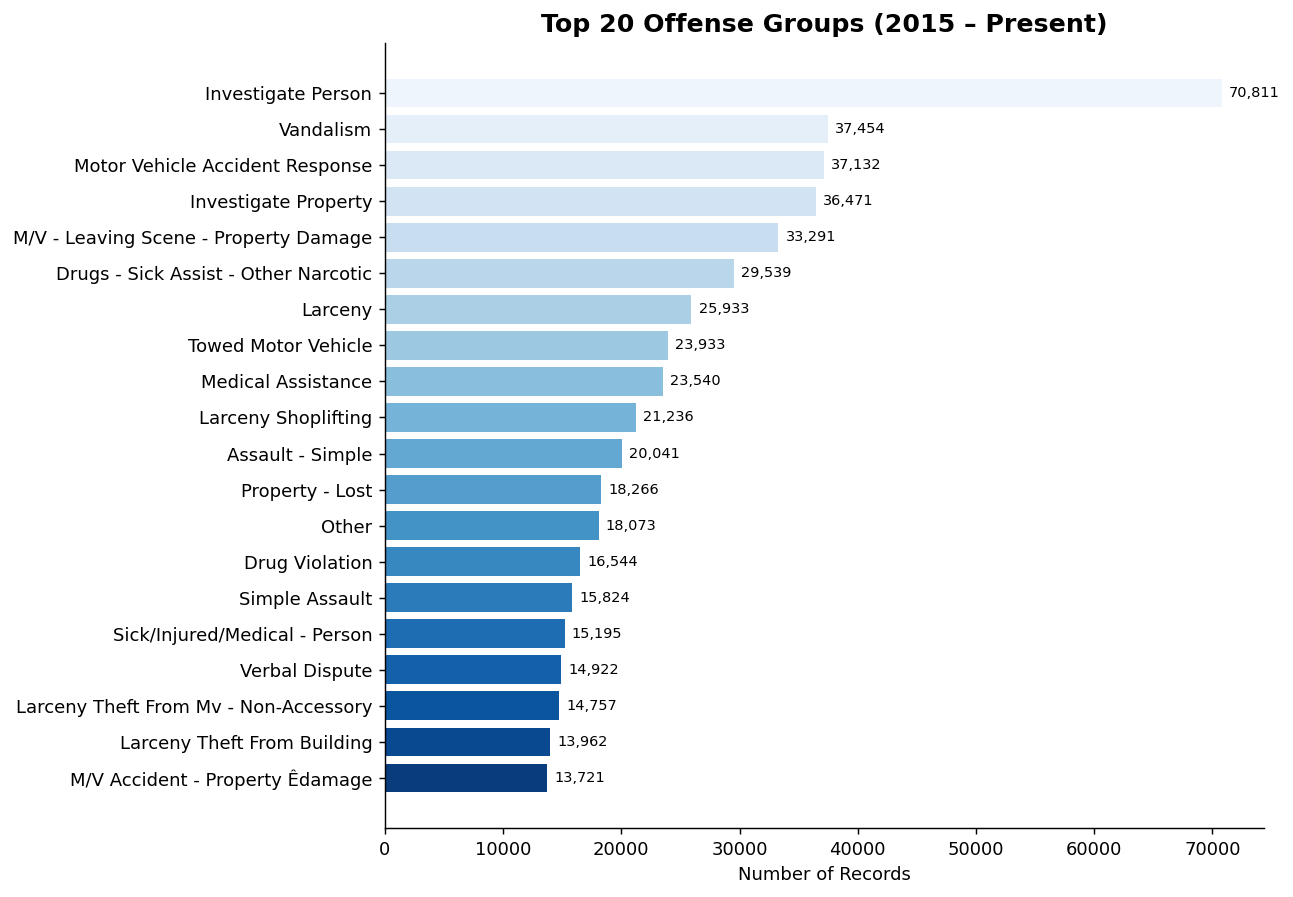

In [6]:
top_n = 20
crime_counts = (df['OFFENSE_CODE_GROUP']
                .value_counts()
                .head(top_n)
                .reset_index()
                .rename(columns={'count':'Count', 'OFFENSE_CODE_GROUP':'Offense Group'}))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(crime_counts['Offense Group'][::-1],
               crime_counts['Count'][::-1],
               color=sns.color_palette('Blues_r', top_n))
ax.bar_label(bars, labels=[f'{v:,}' for v in crime_counts['Count'][::-1]],
             padding=4, fontsize=8)
ax.set_xlabel('Number of Records')
ax.set_title(f'Top {top_n} Offense Groups (2015 – Present)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

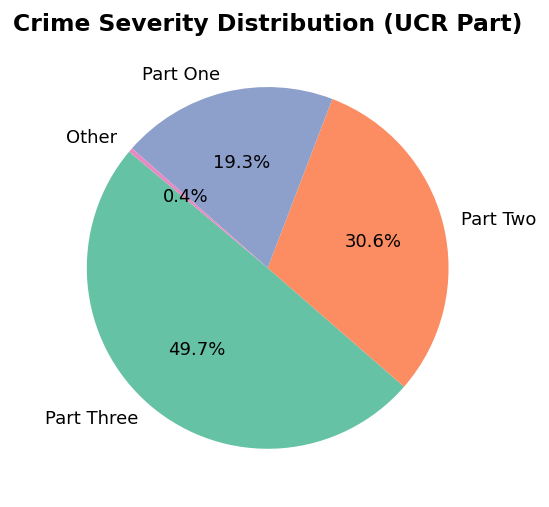

UCR_PART
Part Three    158534
Part Two       97557
Part One       61625
Other           1232


In [7]:
# UCR Part breakdown (severity classification)
ucr_counts = df['UCR_PART'].value_counts().dropna()

fig, ax = plt.subplots(figsize=(6, 4))
wedges, texts, autotexts = ax.pie(
    ucr_counts, labels=ucr_counts.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Set2', len(ucr_counts)))
ax.set_title('Crime Severity Distribution (UCR Part)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(ucr_counts.to_string())

---
## 5  Question 2 — Where Do Crimes Occur?

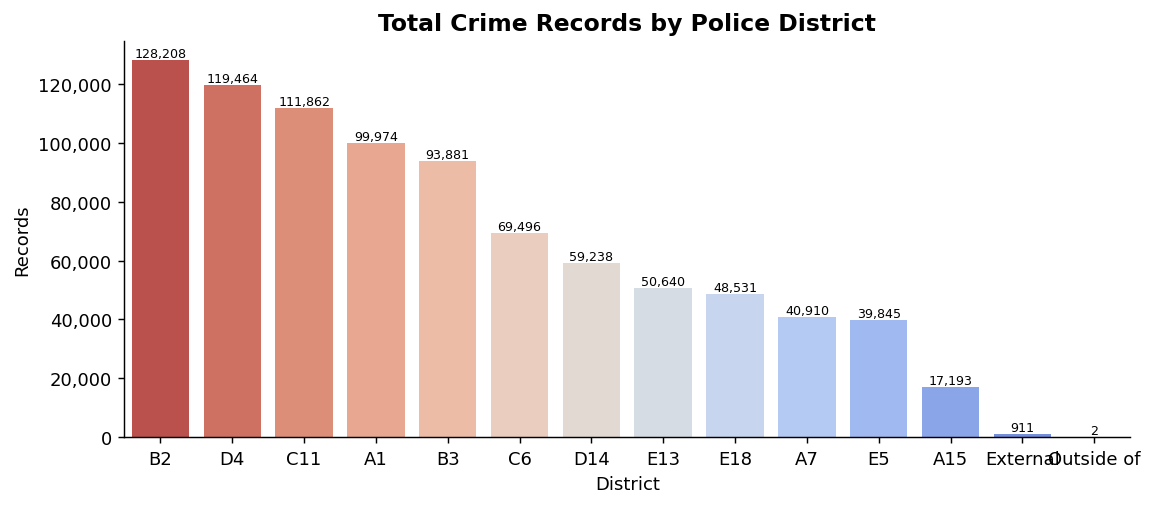

In [8]:
# Crimes by police district
district_counts = (df.groupby('DISTRICT')
                     .size()
                     .sort_values(ascending=False)
                     .reset_index(name='Count'))
district_counts = district_counts[district_counts['DISTRICT'].notna()]

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=district_counts, x='DISTRICT', y='Count', ax=ax,
            palette='coolwarm_r')
ax.set_title('Total Crime Records by Police District', fontsize=13, fontweight='bold')
ax.set_xlabel('District'); ax.set_ylabel('Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

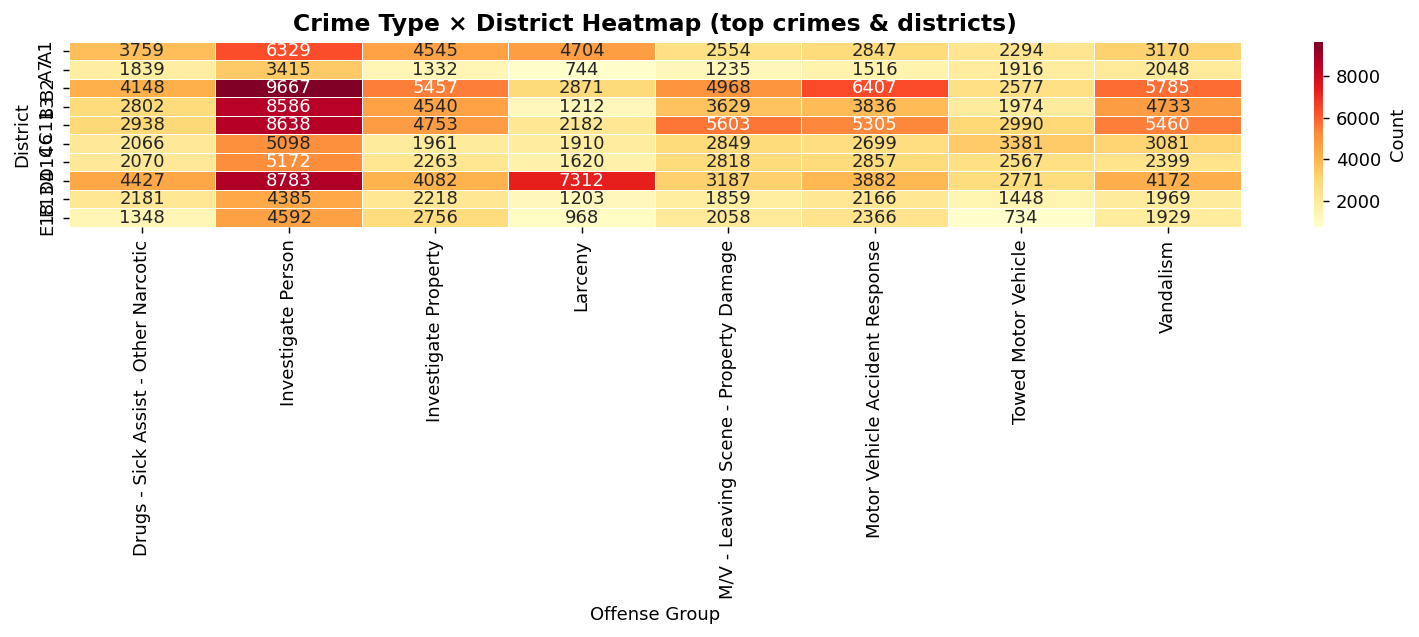

In [9]:
# Top 8 crime types × top 10 districts heatmap
top_districts = district_counts['DISTRICT'].head(10).tolist()
top_crimes    = df['OFFENSE_CODE_GROUP'].value_counts().head(8).index.tolist()

heat_df = (df[df['DISTRICT'].isin(top_districts) & df['OFFENSE_CODE_GROUP'].isin(top_crimes)]
           .groupby(['DISTRICT','OFFENSE_CODE_GROUP'])
           .size()
           .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_df, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Crime Type × District Heatmap (top crimes & districts)', fontsize=13, fontweight='bold')
ax.set_xlabel('Offense Group'); ax.set_ylabel('District')
plt.tight_layout()
plt.show()

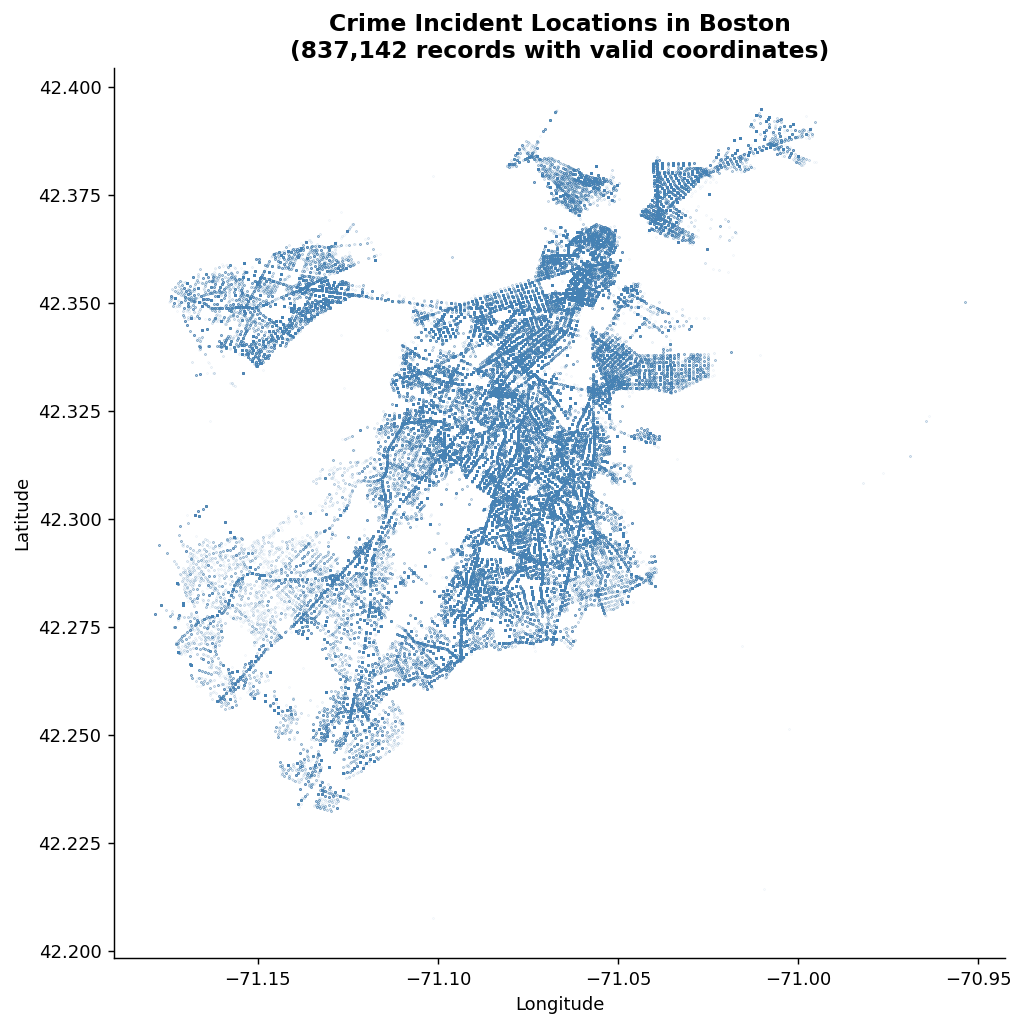

In [10]:
# Geographic scatter plot (valid coords only)
geo = df.dropna(subset=['Lat','Long'])
geo = geo[(geo['Lat'].between(42.2, 42.4)) & (geo['Long'].between(-71.2, -70.9))]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(geo['Long'], geo['Lat'],
           s=0.05, alpha=0.15, color='steelblue', rasterized=True)
ax.set_title(f'Crime Incident Locations in Boston\n({len(geo):,} records with valid coordinates)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

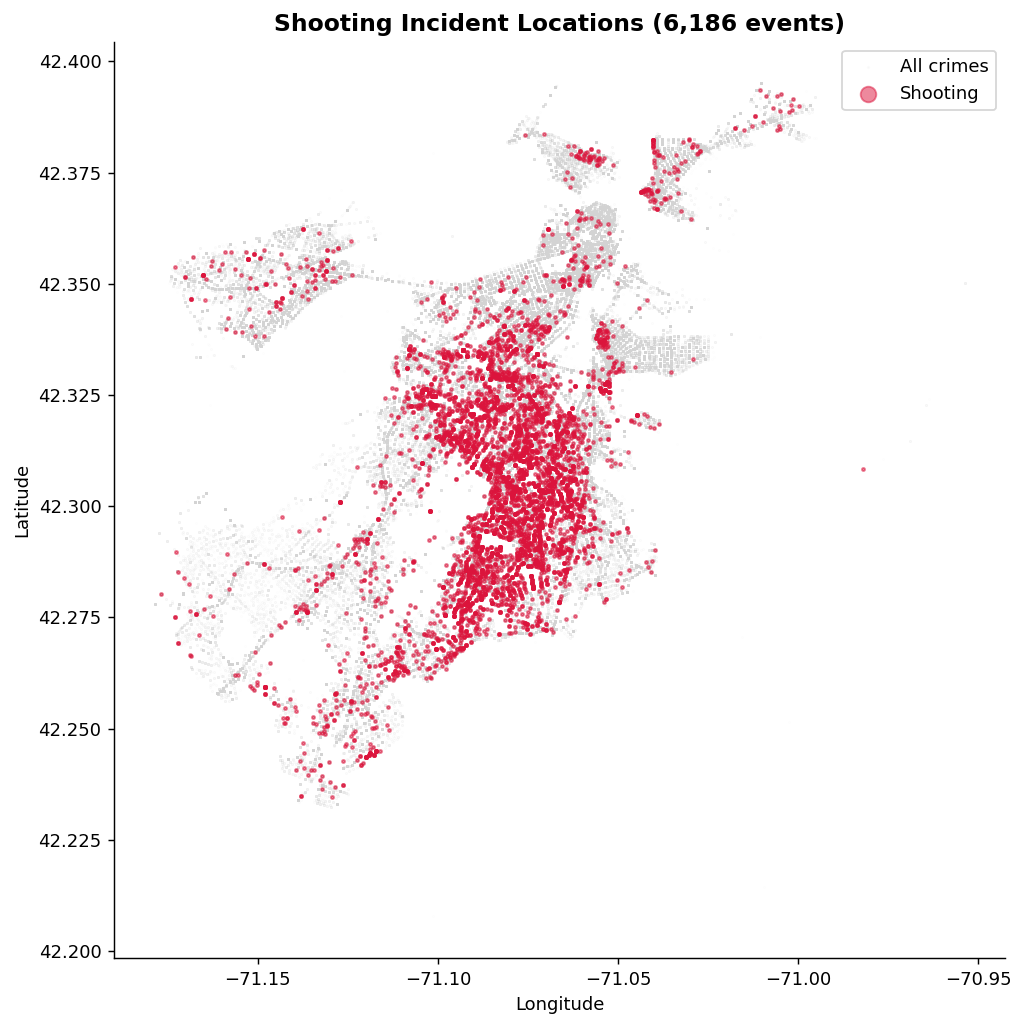

In [11]:
# Shooting incidents on map
geo_shoot = geo[geo['SHOOTING'] == 1]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(geo['Long'], geo['Lat'], s=0.03, alpha=0.08, color='lightgrey', label='All crimes')
ax.scatter(geo_shoot['Long'], geo_shoot['Lat'],
           s=3, alpha=0.5, color='crimson', label='Shooting')
ax.set_title(f'Shooting Incident Locations ({len(geo_shoot):,} events)', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

---
## 6  Question 3 — How Does Crime Frequency Change Over Time?

### 6.1  Hour of Day

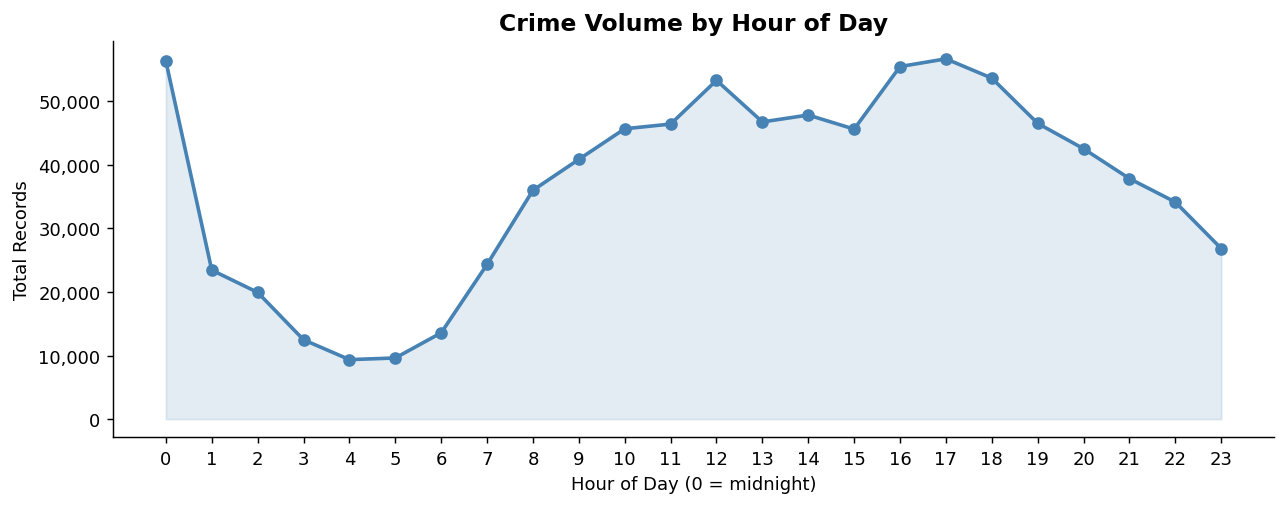

In [12]:
hourly = df.groupby('HOUR').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly['HOUR'], hourly['Count'], marker='o', linewidth=2, color='steelblue')
ax.fill_between(hourly['HOUR'], hourly['Count'], alpha=0.15, color='steelblue')
ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of Day (0 = midnight)')
ax.set_ylabel('Total Records')
ax.set_title('Crime Volume by Hour of Day', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### 6.2  Day of Week

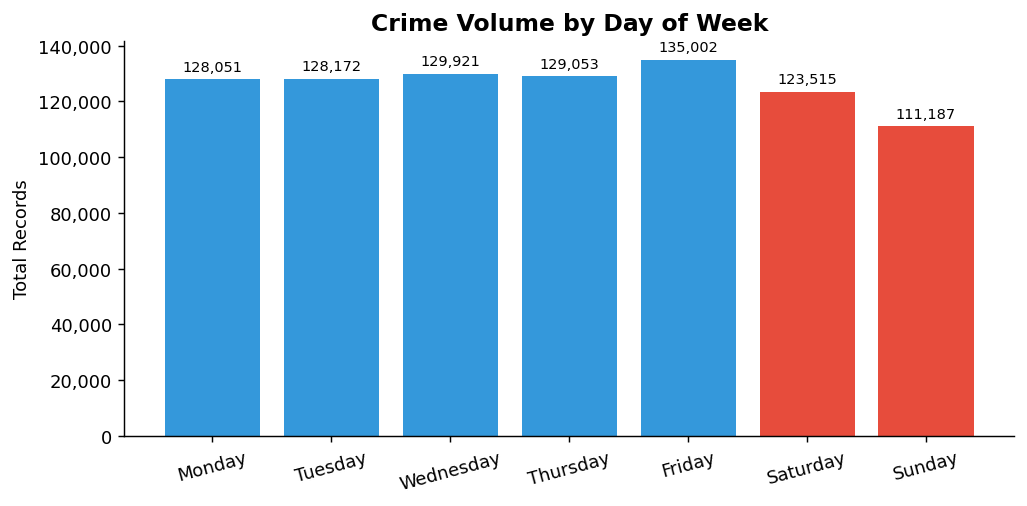

In [13]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly = df.groupby('DAY_OF_WEEK').size().reindex(day_order).reset_index(name='Count')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if d in ('Saturday','Sunday') else '#3498db' for d in day_order]
bars = ax.bar(weekly['DAY_OF_WEEK'], weekly['Count'], color=colors)
ax.bar_label(bars, labels=[f'{v:,}' for v in weekly['Count']], padding=3, fontsize=8)
ax.set_title('Crime Volume by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 6.3  Month of Year

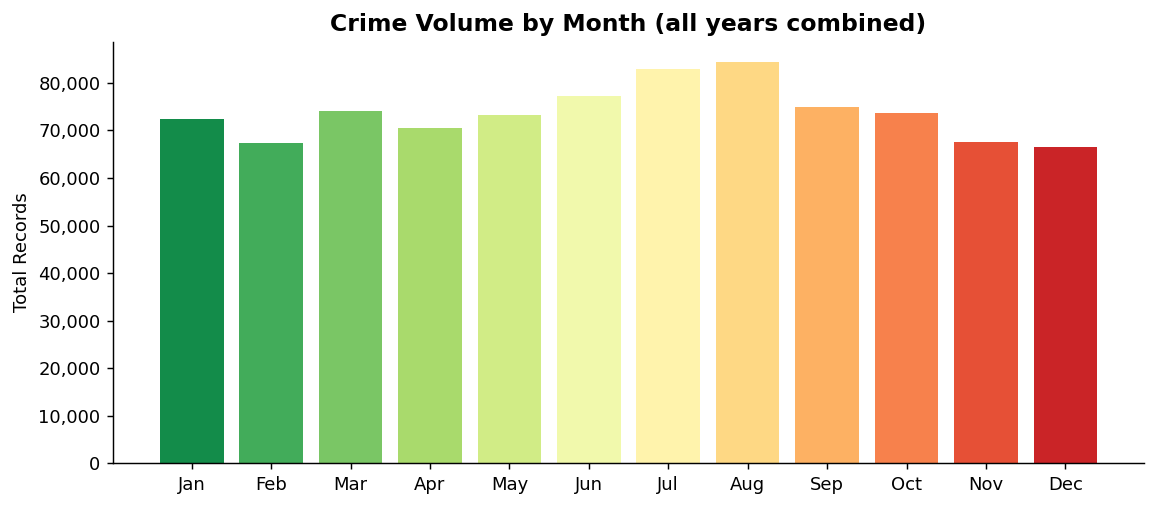

In [14]:
monthly = df.groupby('MONTH').size().reset_index(name='Count')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly['MONTH'], monthly['Count'],
       color=sns.color_palette('RdYlGn_r', 12))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Crime Volume by Month (all years combined)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### 6.4  Annual Trend

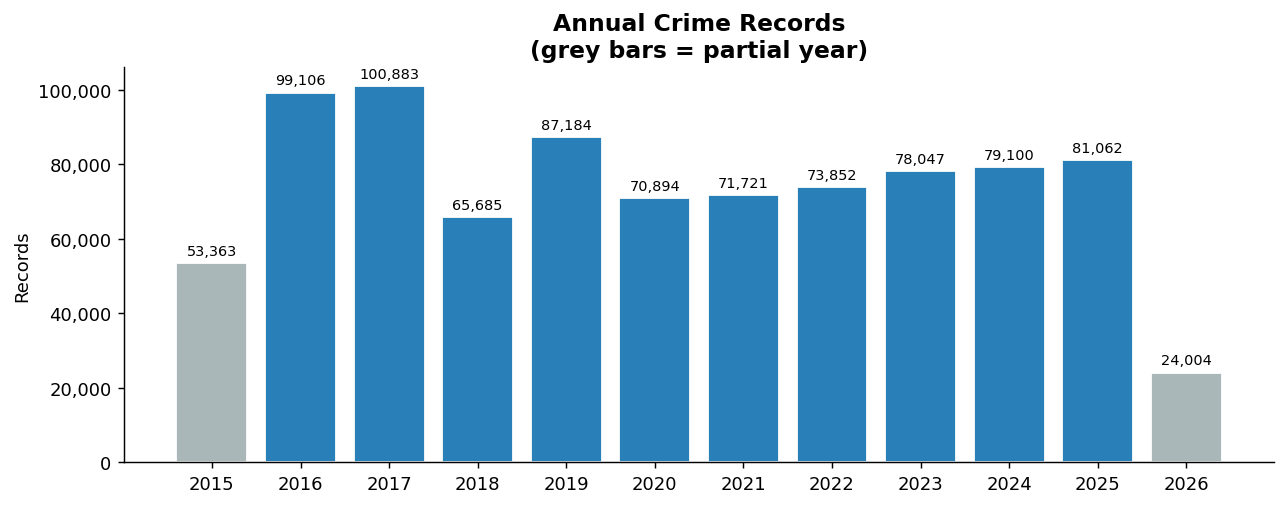

In [15]:
# Partial-year caution: 2015 starts mid-June; 2026 is partial
yearly = df.groupby('YEAR').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly['YEAR'], yearly['Count'],
       color=['#aab7b8' if y in (2015, 2026) else '#2980b9' for y in yearly['YEAR']],
       edgecolor='white')
ax.bar_label(ax.containers[0], labels=[f'{v:,}' for v in yearly['Count']],
             padding=3, fontsize=8)
ax.set_title('Annual Crime Records\n(grey bars = partial year)', fontsize=13, fontweight='bold')
ax.set_ylabel('Records')
ax.set_xticks(yearly['YEAR'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

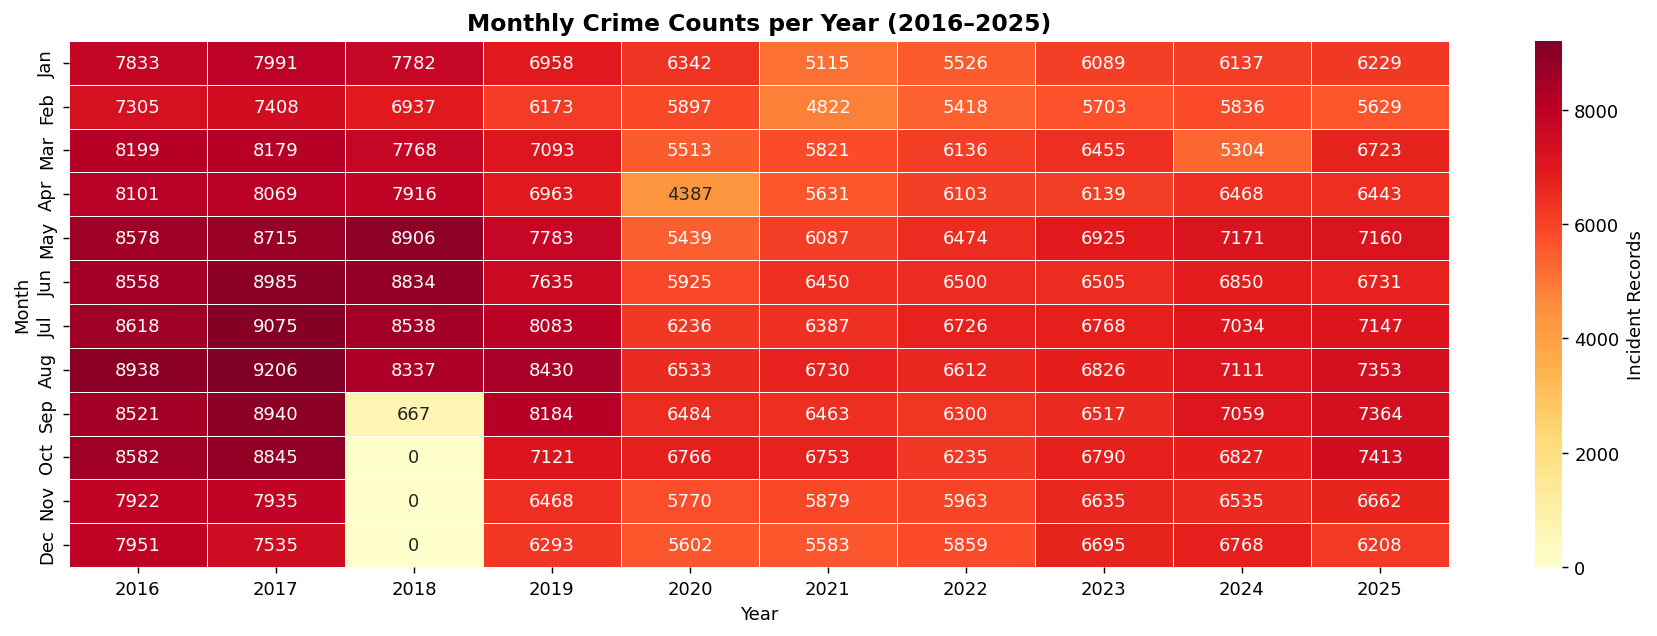

In [16]:
# Month-Year heatmap (complete years only: 2016-2025)
df_full = df[df['YEAR'].between(2016, 2025)]
pivot = (df_full.pivot_table(index='MONTH', columns='YEAR',
                              values='INCIDENT_NUMBER', aggfunc='count')
               .fillna(0)
               .astype(int))
pivot.index = month_labels

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Incident Records'})
ax.set_title('Monthly Crime Counts per Year (2016–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

### 6.5  Hour × Day-of-Week Interaction Heatmap

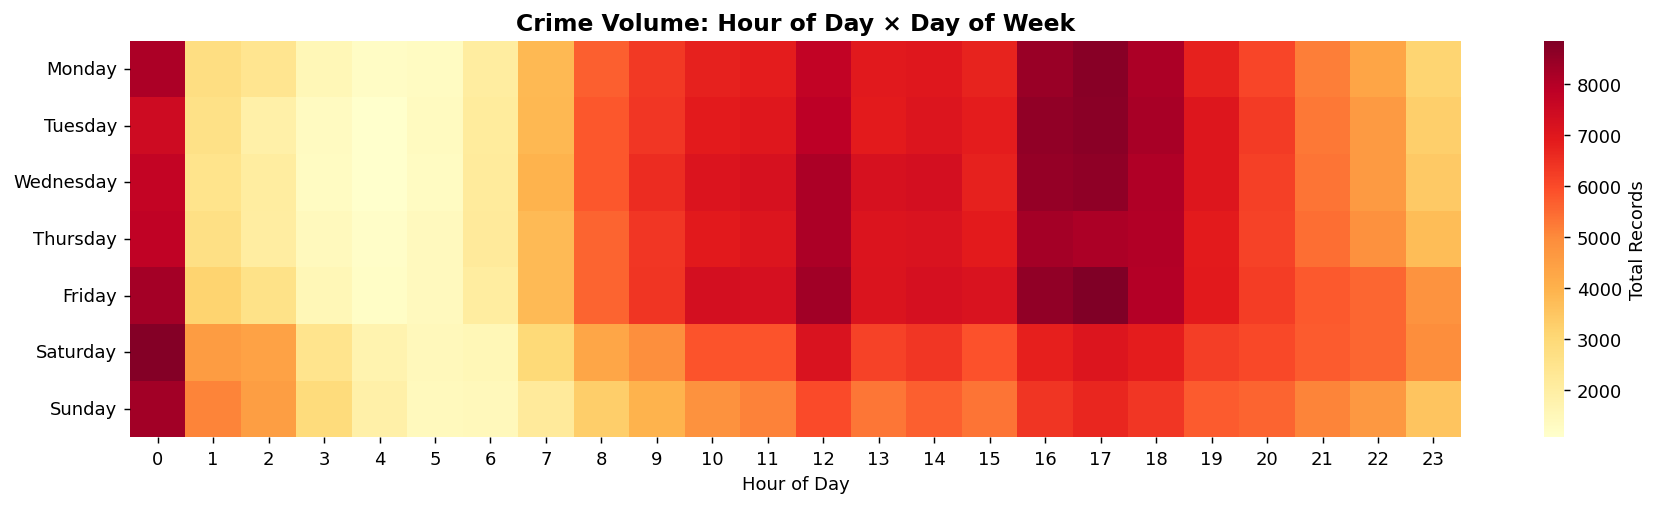

In [17]:
hour_day = (df.groupby(['DAY_OF_WEEK','HOUR'])
              .size()
              .unstack()
              .reindex(day_order))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(hour_day, cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Total Records'})
ax.set_title('Crime Volume: Hour of Day × Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 7  Deep-Dive: Top Crime Categories Over Time

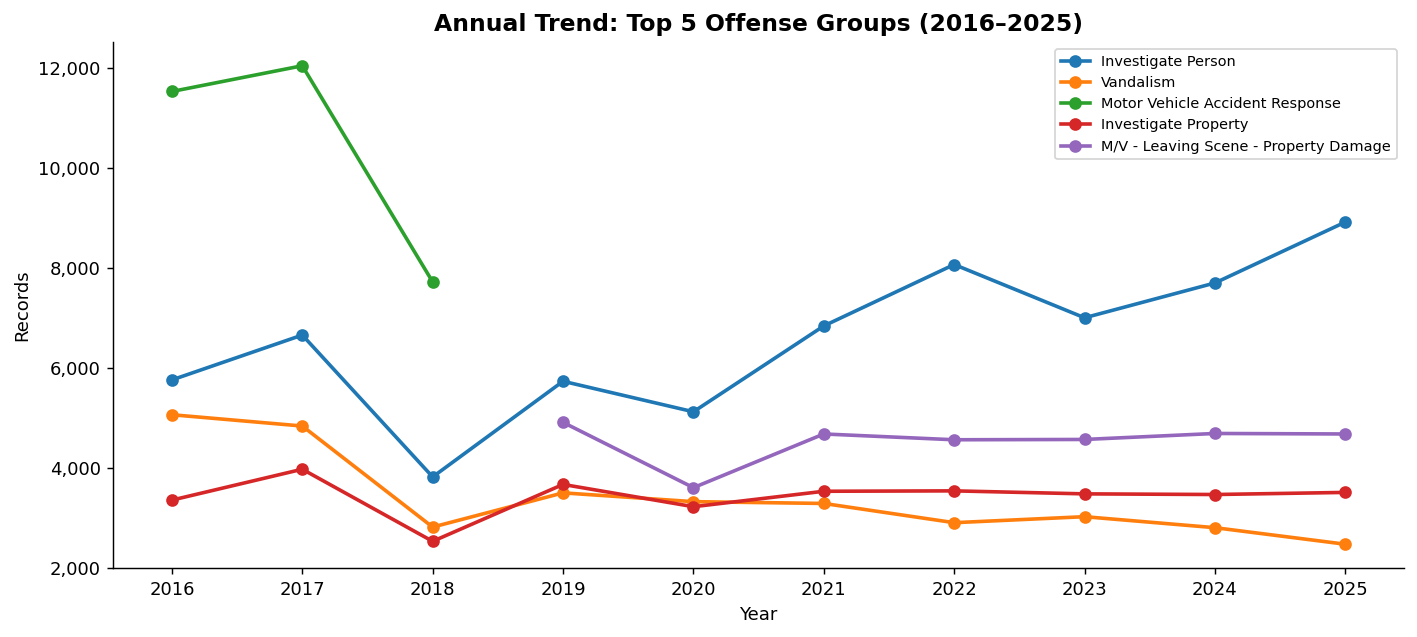

In [18]:
top5_crimes = df['OFFENSE_CODE_GROUP'].value_counts().head(5).index.tolist()

annual_by_type = (df[df['OFFENSE_CODE_GROUP'].isin(top5_crimes)]
                  .groupby(['YEAR','OFFENSE_CODE_GROUP'])
                  .size()
                  .reset_index(name='Count'))

# Exclude 2015 (partial) and current partial year for cleaner trend
annual_by_type = annual_by_type[annual_by_type['YEAR'].between(2016, 2025)]

fig, ax = plt.subplots(figsize=(11, 5))
for crime in top5_crimes:
    sub = annual_by_type[annual_by_type['OFFENSE_CODE_GROUP'] == crime]
    ax.plot(sub['YEAR'], sub['Count'], marker='o', label=crime, linewidth=2)

ax.set_title('Annual Trend: Top 5 Offense Groups (2016–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Records')
ax.set_xticks(range(2016, 2026))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 8  Shooting Incidents Analysis

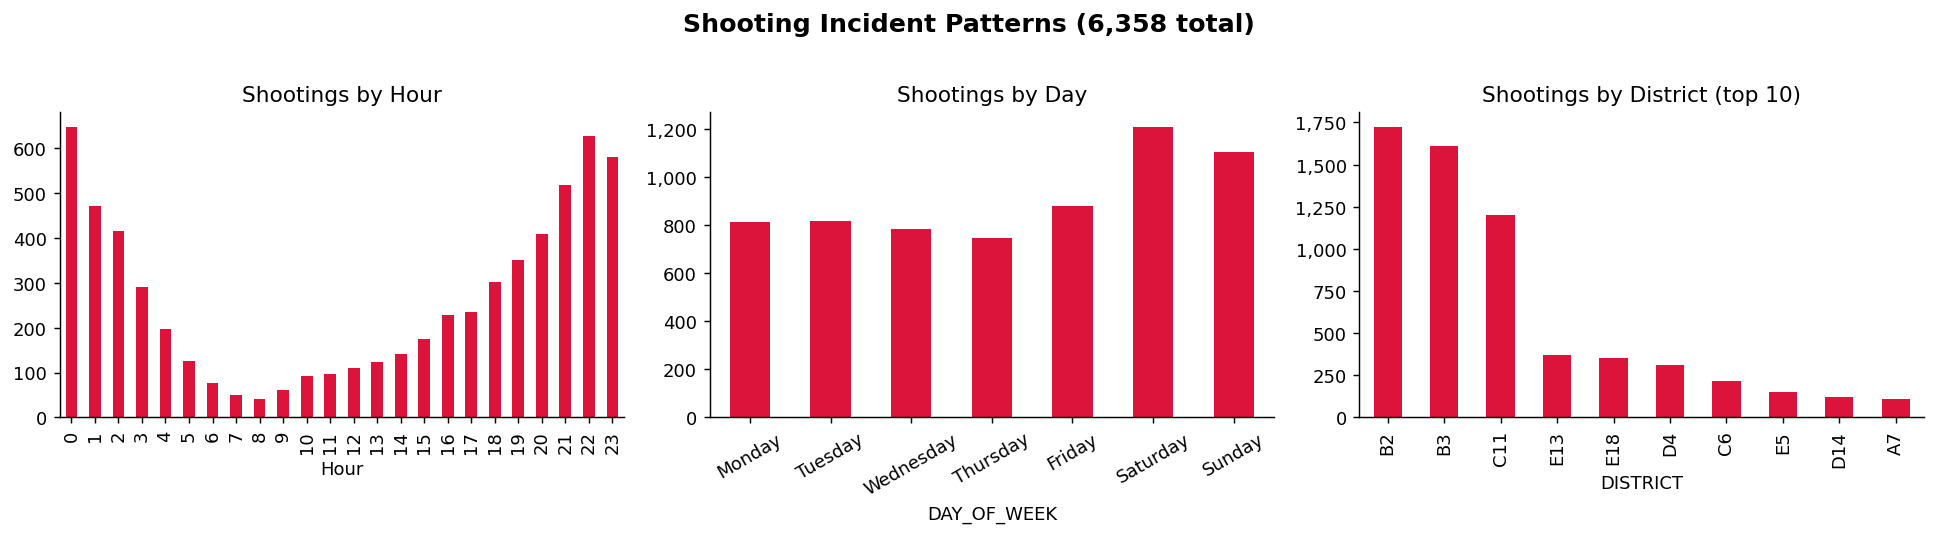

In [19]:
shootings = df[df['SHOOTING'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# By hour
shootings.groupby('HOUR').size().plot(kind='bar', ax=axes[0], color='crimson')
axes[0].set_title('Shootings by Hour'); axes[0].set_xlabel('Hour')

# By day
shoot_day = shootings.groupby('DAY_OF_WEEK').size().reindex(day_order)
shoot_day.plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Shootings by Day'); axes[1].tick_params(axis='x', rotation=30)

# By district
shoot_dist = shootings.groupby('DISTRICT').size().sort_values(ascending=False).head(10)
shoot_dist.plot(kind='bar', ax=axes[2], color='crimson')
axes[2].set_title('Shootings by District (top 10)')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(f'Shooting Incident Patterns ({len(shootings):,} total)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

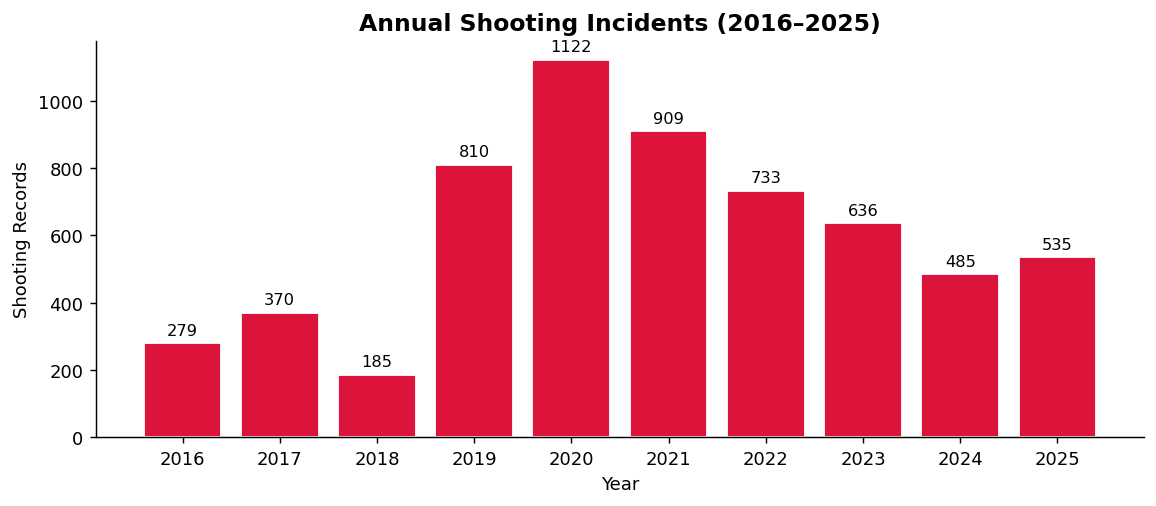

In [20]:
# Annual shooting trend
shoot_yr = shootings.groupby('YEAR').size().reset_index(name='Shootings')
shoot_yr = shoot_yr[shoot_yr['YEAR'].between(2016, 2025)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(shoot_yr['YEAR'], shoot_yr['Shootings'], color='crimson', edgecolor='white')
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
ax.set_title('Annual Shooting Incidents (2016–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Shooting Records'); ax.set_xlabel('Year')
ax.set_xticks(shoot_yr['YEAR'])
plt.tight_layout()
plt.show()

---
## 9  Street-Level Hot Spots

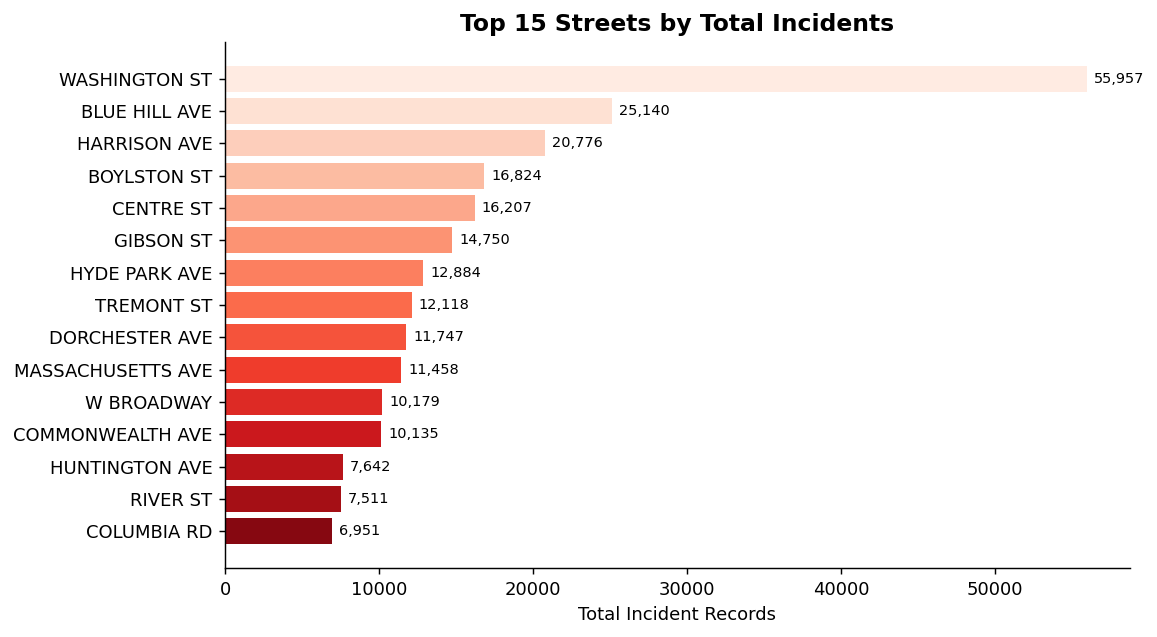

In [21]:
top_streets = (df['STREET'].value_counts()
                .dropna()
                .head(15)
                .reset_index()
                .rename(columns={'count':'Count', 'STREET':'Street'}))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_streets['Street'][::-1], top_streets['Count'][::-1],
               color=sns.color_palette('Reds_r', 15))
ax.bar_label(bars, labels=[f'{v:,}' for v in top_streets['Count'][::-1]],
             padding=4, fontsize=8)
ax.set_title('Top 15 Streets by Total Incidents', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Incident Records')
plt.tight_layout()
plt.show()

---
## 10  COVID-19 Impact (2019 vs 2020 vs 2021)

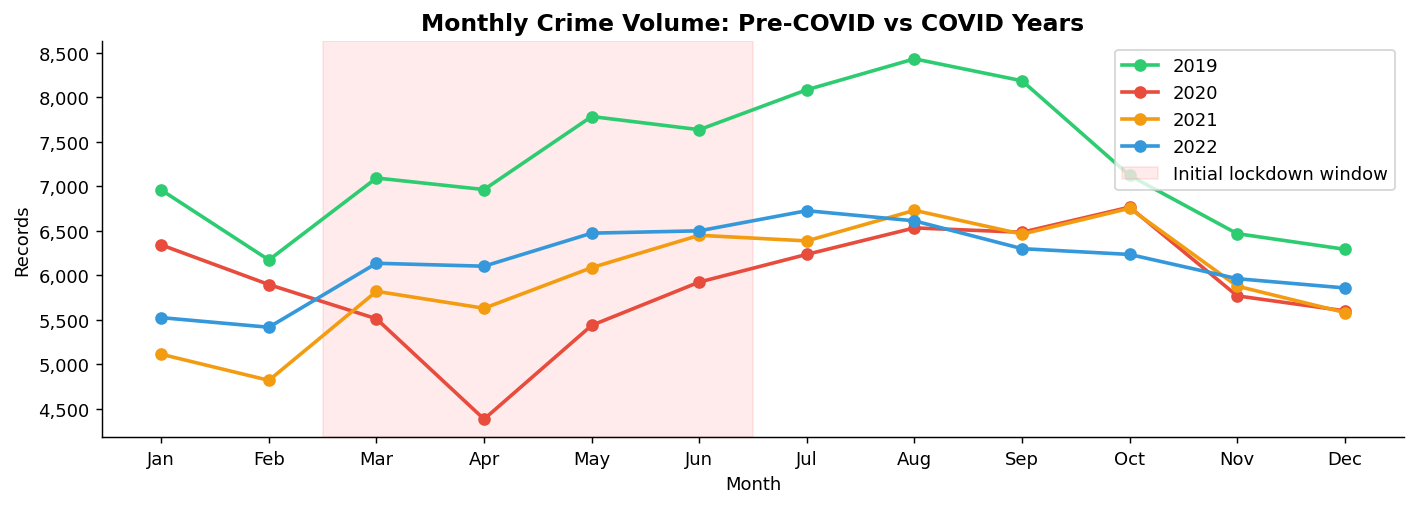

In [22]:
covid_years = [2019, 2020, 2021, 2022]
covid_df = df[df['YEAR'].isin(covid_years)]

# Monthly pattern comparison
covid_monthly = (covid_df.groupby(['YEAR','MONTH'])
                  .size()
                  .reset_index(name='Count'))

fig, ax = plt.subplots(figsize=(11, 4))
palette = {2019: '#2ecc71', 2020: '#e74c3c', 2021: '#f39c12', 2022: '#3498db'}
for yr in covid_years:
    sub = covid_monthly[covid_monthly['YEAR'] == yr]
    ax.plot(sub['MONTH'], sub['Count'], marker='o', label=str(yr),
            color=palette[yr], linewidth=2)

ax.axvspan(2.5, 6.5, color='red', alpha=0.08, label='Initial lockdown window')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Monthly Crime Volume: Pre-COVID vs COVID Years',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Records'); ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 11  Summary of Key Findings

In [23]:
top3 = df['OFFENSE_CODE_GROUP'].value_counts().head(3)
peak_hour = df.groupby('HOUR').size().idxmax()
peak_day  = df.groupby('DAY_OF_WEEK').size().idxmax()
busiest_district = df.groupby('DISTRICT').size().idxmax()
busiest_street   = df['STREET'].value_counts().idxmax()

print('=== KEY FINDINGS ===')
print(f'\n1. Most common crimes:')
for rank, (crime, cnt) in enumerate(top3.items(), 1):
    print(f'   {rank}. {crime}  ({cnt:,})')

print(f'\n2. Crime peaks at hour {peak_hour}:00 on {peak_day}s.')
print(f'3. Busiest police district: {busiest_district}')
print(f'4. Highest incident street: {busiest_street}')
print(f'5. Total shooting incidents: {df["SHOOTING"].sum():,}'  
      f' ({df["SHOOTING"].mean()*100:.2f}% of all records)')
print(f'6. 2020 (COVID) saw a drop in crime; 2021–2022 rebounded.')

=== KEY FINDINGS ===

1. Most common crimes:
   1. Investigate Person  (70,811)
   2. Vandalism  (37,454)
   3. Motor Vehicle Accident Response  (37,132)

2. Crime peaks at hour 17:00 on Fridays.
3. Busiest police district: B2
4. Highest incident street: WASHINGTON ST
5. Total shooting incidents: 6,358 (0.72% of all records)
6. 2020 (COVID) saw a drop in crime; 2021–2022 rebounded.
